# Scientific Track: ANNNI Phase Diagram Under Noise

Welcome to the Bitcamp 2026 theory challenge.

Your task: use PennyLane to **map the phase diagram** of the 1D Axial Next-Nearest-Neighbor
Ising (ANNNI) model in the $(\kappa, h)$ plane, then study how **depolarizing gate noise**
distorts the phase boundaries.

This notebook walks through the core tools from the starter kit and gets you to a working
clean-phase diagram so you can focus your hackathon time on the noise analysis and
physical interpretation.

Sections:
1. **The ANNNI model** — Hamiltonian, coupling structure, and the three competing forces
2. **Reading phase identity from observables** — what exact diagonalization tells us at four representative points
3. **Clean phase survey** — a full $(\kappa, h)$ grid with analytical boundaries overlaid
4. **The noise model** — depolarizing channels and what they do to order parameters
5. **Your phase diagrams** — workspace to build the noisy scans for submission

Read the `README.md` handout alongside this notebook for the full problem statement and
judging rubric.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/mpl-scientific-track")

NOTEBOOK_DIR = Path.cwd()
if (NOTEBOOK_DIR / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR))
elif (NOTEBOOK_DIR / "Scientific Track" / "starter_kit").exists():
    sys.path.insert(0, str(NOTEBOOK_DIR / "Scientific Track"))

import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
from IPython.display import HTML, display

from starter_kit import (
    animate_linecut,
    build_annni_hamiltonian,
    bkt_transition,
    exact_ground_state,
    ising_transition,
    kt_transition,
    noisy_entangling_layer,
    order_parameter_summary,
    plot_coupling_graph,
    plot_observable_heatmap,
    simple_noisy_energy,
)

print(f"PennyLane version: {qml.__version__}")
print(f"NumPy version: {np.__version__}")

# All worked examples use N=6 for speed.  Your submission should target N≥8.
DEMO_N = 6

PennyLane version: 0.44.1
NumPy version: 2.5.3


## 1. The ANNNI Model

The 1D ANNNI Hamiltonian has three terms that **compete** against each other:

$$H = -J_1 \sum_i Z_i Z_{i+1} \;+\; J_1 \kappa \sum_i Z_i Z_{i+2} \;-\; h \sum_i X_i$$

| Term | Force | Wins when… |
|---|---|---|
| $-Z_i Z_{i+1}$ | Nearest-neighbor spins want to **align** (ferromagnetic) | $\kappa$ small, $h$ small |
| $+\kappa Z_i Z_{i+2}$ | Next-nearest spins want to **anti-align** (frustration) | $\kappa > 0.5$, $h$ small |
| $-h X_i$ | External field tries to **rotate** all spins out of the $Z$ basis | $h$ large |

Two dimensionless ratios parametrize the model: **$\kappa = |J_2|/J_1$** (frustration
strength, swept 0→1) and **$h/J_1$** (field strength, swept 0→2).  We set $J_1 = 1$.

The starter kit uses periodic boundary conditions and the $Z/Z/X$ convention throughout.
The PennyLane ANNNI demo uses an open-chain $X/X/Z$ convention — the physics is the same
but the analytical boundary formulas can look slightly different at finite $N$.

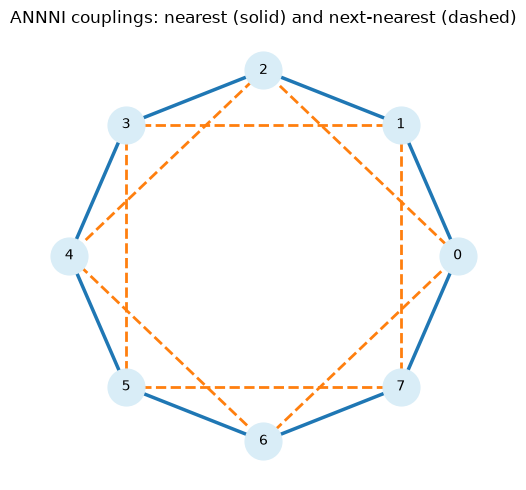

ANNNI Hamiltonian at kappa=0.3, h=0.5, N=6:
  Number of terms: 18

First few terms (coefficient × operator):
  -1.00 × Z(0) @ Z(1)
  -1.00 × Z(1) @ Z(2)
  -1.00 × Z(2) @ Z(3)
  -1.00 × Z(3) @ Z(4)
  -1.00 × Z(4) @ Z(5)
  -1.00 × Z(5) @ Z(0)
  ...


In [2]:
# Draw the coupling graph: solid = nearest-neighbor, dashed = next-nearest-neighbor (frustration)
fig, ax = plot_coupling_graph(n_qubits=8, periodic=True)
plt.tight_layout()
plt.show()

# Build the Hamiltonian at a sample point and inspect it
# qml.dot returns a Sum of SProd terms; each SProd has .scalar (coefficient) and .base (operator)
H_sample = build_annni_hamiltonian(n_qubits=DEMO_N, kappa=0.3, h=0.5)
print(f"ANNNI Hamiltonian at kappa=0.3, h=0.5, N={DEMO_N}:")
print(f"  Number of terms: {len(H_sample.operands)}")
print()
print("First few terms (coefficient × operator):")
for term in list(H_sample.operands)[:6]:
    print(f"  {float(term.scalar):+.2f} × {term.base}")
print("  ...")

## 2. Reading Phase Identity From Observables

We detect phases by measuring **order parameters** — quantities that take different values
in different phases.  The starter kit computes these from the exact ground-state vector:

| Observable | Symbol | Large positive value means… |
|---|---|---|
| Nearest-neighbor correlation | $\langle Z_i Z_{i+1} \rangle$ | Spins align → **ferromagnetic** |
| Next-nearest correlation | $\langle Z_i Z_{i+2} \rangle$ | Spins two sites apart are correlated |
| Transverse magnetization | $\langle X_i \rangle$ | Spins align with the field → **paramagnetic** |
| Antiphase string | $\langle Z_i Z_{i+1} \cdot Z_{i+2} Z_{i+3} \rangle$ | ↑↑↓↓ pattern → **antiphase** |

**Important caveat**: finite-size ground states often preserve global $\mathbb{Z}_2$
symmetry, so the raw magnetization $\langle Z_i \rangle$ stays near zero even in the
ferromagnetic phase.  Correlation-based observables are more reliable at small $N$.

Below we sample four representative $(\kappa, h)$ points — one per phase — and read the
observables. Use these to calibrate your intuition before scanning the full grid.

In [3]:
# Four representative points: (kappa, h, expected phase)
sample_points = [
    (0.20, 0.20, "ferromagnetic   "),
    (0.80, 0.20, "antiphase       "),
    (0.20, 1.60, "paramagnetic    "),
    (0.70, 0.90, "near-boundary   "),
]

header = (f"{'(kappa, h)':>14s}  {'phase':18s}  "
          f"{'gap':>7s}  {'ZZ_nn':>7s}  {'ZZ_nnn':>7s}  {'X':>7s}  {'AP_str':>7s}")
print(header)
print("─" * len(header))

for kappa, h, label in sample_points:
    res = exact_ground_state(n_qubits=DEMO_N, kappa=kappa, h=h, periodic=True)
    s = res["summary"]
    print(f"  ({kappa:.2f}, {h:.2f}):    {label}  "
          f"{res['energy_gap']:7.4f}  "
          f"{s['zz_nearest_mean']:7.4f}  "
          f"{s['zz_next_nearest_mean']:7.4f}  "
          f"{s['x_mean']:7.4f}  "
          f"{s['antiphase_string_mean']:7.4f}")

    (kappa, h)  phase                   gap    ZZ_nn   ZZ_nnn        X   AP_str
───────────────────────────────────────────────────────────────────────────────
  (0.20, 0.20):    ferromagnetic      0.0002   0.9838   0.9833   0.1276   0.9678
  (0.80, 0.20):    antiphase          0.0883   0.3296  -0.3279   0.5524   0.1087
  (0.20, 1.60):    paramagnetic       1.7848   0.2707   0.0523   0.9245   0.0733
  (0.70, 0.90):    near-boundary      0.7644   0.2711  -0.2217   0.8131   0.0735


**Interpretation guide**:

- **Ferromagnetic** $(\kappa$ small, $h$ small): $\langle Z_i Z_{i+1} \rangle$ large and
  positive (neighboring spins aligned); $\langle X \rangle$ small.
- **Antiphase** $(\kappa > 0.5$, $h$ small): $\langle Z_i Z_{i+2} \rangle$ strongly
  *negative* (next-nearest anti-aligned); antiphase string $\approx 1$.
- **Paramagnetic** (large $h$): $\langle X \rangle$ large; both correlations suppressed.
- **Near a boundary**: small energy gap, observables change rapidly

The gap column also helps: a **phase transition** happens where the gap closes, so scanning the gap alongside order parameters can locate boundaries.

## 3. Clean Phase Survey

Now let's build a proper $(\kappa, h)$ grid and plot two observables as heatmaps.
We then overlay the **analytical phase boundaries** from the starter kit's `reference.py`.

The three reference lines are:
- **Ising transition** — ferro ↔ para (valid for $\kappa < 0.5$)
- **KT transition** — para ↔ antiphase (valid for $\kappa > 0.5$)
- **BKT transition** — lower boundary of the floating phase (valid for $\kappa > 0.5$)

At finite $N$ with periodic boundaries these are *qualitative* overlays; expect the numerical
boundaries to shift by a few grid squares compared to the thermodynamic-limit formulas.

This scan uses $N=6$ and a 20×20 grid — takes about 30 seconds on most laptops.
Your submission should use a finer grid (≥ 15×15) and $N \geq 8$.

In [4]:
GRID = 20  # increase for finer resolution
kappas = np.linspace(0.0, 1.0, GRID)
hs     = np.linspace(0.0, 2.0, GRID)

zz_nn  = np.zeros((GRID, GRID))
zz_nnn = np.zeros((GRID, GRID))
x_mag  = np.zeros((GRID, GRID))
gap    = np.zeros((GRID, GRID))

print(f"Scanning {GRID}×{GRID} grid at N={DEMO_N} ...")
for row, h in enumerate(hs):
    for col, kappa in enumerate(kappas):
        res = exact_ground_state(n_qubits=DEMO_N, kappa=float(kappa), h=float(h), periodic=True)
        s = res["summary"]
        zz_nn[row, col]  = s["zz_nearest_mean"]
        zz_nnn[row, col] = s["zz_next_nearest_mean"]
        x_mag[row, col]  = s["x_mean"]
        gap[row, col]    = res["energy_gap"]
    if (row + 1) % 5 == 0:
        print(f"  row {row+1}/{GRID} done")

print("Scan complete.")

Scanning 20×20 grid at N=6 ...


  row 5/20 done


  row 10/20 done


  row 15/20 done


  row 20/20 done
Scan complete.


In [ ]:
# Reference boundary curves
kappa_ref = np.linspace(0.0, 1.0, 500)
h_ising = ising_transition(kappa_ref)
h_kt    = kt_transition(kappa_ref)
h_bkt   = bkt_transition(kappa_ref)

import matplotlib.patheffects as pe
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

_boundary_outline = [pe.Stroke(linewidth=3, foreground="white"), pe.Normal()]

def add_boundaries(ax):
    """Overlay analytical phase boundaries on a (kappa, h) heatmap axis."""
    ax.plot(kappa_ref, h_ising, color="black", ls="--", lw=1.8,
            label="Ising (ferro↔para)", path_effects=_boundary_outline)
    ax.plot(kappa_ref, h_kt,    color="black", ls=":",  lw=1.8,
            label="KT (floating↔para)", path_effects=_boundary_outline)
    ax.plot(kappa_ref, h_bkt,   color="black", ls="-.", lw=1.8,
            label="BKT (antiphase↔floating)", path_effects=_boundary_outline)
    # kappa=0.5 is the multicritical point: the Ising line (ferro<->para) is only
    # valid to its left; KT/BKT (floating phase boundaries) only exist to its right.
    ax.axvline(0.5, color="black", lw=1.0, alpha=0.7, linestyle="--",
               label=r"$\kappa=0.5$ (multicritical point)", path_effects=_boundary_outline)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.7)

def add_floating_shading(ax):
    """Hatch the analytical floating-phase window (between the BKT and KT lines,
    kappa > 0.5). A 3-way argmax over {ferro, antiphase, para} order has no bucket
    for a fourth phase, and Section 7 shows the local order parameters can't resolve
    it empirically at N=8 either -- so the region is drawn from the analytical
    boundaries rather than the classifier, and flagged as such in the legend."""
    mask = kappa_ref > 0.5
    ax.fill_between(kappa_ref[mask], h_bkt[mask], h_kt[mask],
                     facecolor="#CC79A7", alpha=0.55, edgecolor="black", hatch="////",
                     linewidth=0.0, zorder=2.5)

# Unified categorical panel: classify each grid point by whichever order parameter
# is largest, so the phase map reads as one consolidated diagram (not just 3
# separate continuous heatmaps). Okabe-Ito colorblind-safe triple. Labels use the
# same bra-ket notation as the heatmap titles above for consistency.
PHASE_NAMES  = [r"Ferro ($\langle Z_iZ_{i+1}\rangle$)", r"Antiphase ($\langle Z_iZ_{i+2}\rangle$)",
                r"Para ($\langle X\rangle$)"]
PHASE_COLORS = ["#0072B2", "#D55E00", "#009E73"]
_phase_cmap = ListedColormap(PHASE_COLORS)
_phase_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], _phase_cmap.N)

def classify_phase(zz_nn_grid, zz_nnn_grid, x_mag_grid):
    """argmax over {ferro order, antiphase order, para order} at each grid point.
    This 3-way argmax has no bucket for the floating phase -- see add_floating_shading
    and Section 7 for why, and how the floating window is drawn instead."""
    scores = np.stack([zz_nn_grid, -zz_nnn_grid, x_mag_grid], axis=0)
    return np.argmax(scores, axis=0)

def add_phase_panel(ax, zz_nn_grid, zz_nnn_grid, x_mag_grid, kappas, hs):
    phase = classify_phase(zz_nn_grid, zz_nnn_grid, x_mag_grid)
    ax.imshow(
        phase, origin="lower", aspect="auto",
        extent=[kappas.min(), kappas.max(), hs.min(), hs.max()],
        cmap=_phase_cmap, norm=_phase_norm,
    )
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$h$")
    ax.set_title("Dominant order parameter", fontsize=10)
    add_floating_shading(ax)
    add_boundaries(ax)
    boundary_legend = ax.get_legend()
    ax.add_artist(boundary_legend)
    argmax_handles = [Patch(facecolor=c, label=n) for c, n in zip(PHASE_COLORS, PHASE_NAMES)]
    argmax_handles.append(Patch(facecolor="#CC79A7", alpha=0.55, edgecolor="black", hatch="////",
                                 label="Floating (analytical BKT-KT window)"))
    # Placed fully outside the axes (to the right) so it never overlaps plotted data,
    # unlike an in-axis corner which the data can cover depending on kappa/p.
    ax.legend(handles=argmax_handles, loc="upper left", bbox_to_anchor=(1.02, 1.0),
               fontsize=7, framealpha=0.7, title="argmax", borderaxespad=0.0)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))

observables = [
    (zz_nn,  r"$\langle Z_i Z_{i+1} \rangle$  (ferro order)",  "RdBu_r"),
    (zz_nnn, r"$\langle Z_i Z_{i+2} \rangle$  (antiphase order)", "RdBu_r"),
    (x_mag,  r"$\langle X \rangle$  (para order)",              "viridis"),
]

for ax, (values, title, cmap) in zip(axes[:3], observables):
    im = ax.imshow(
        values,
        origin="lower",
        aspect="auto",
        extent=[kappas.min(), kappas.max(), hs.min(), hs.max()],
        cmap=cmap,
        vmin=-1, vmax=1,
    )
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$h$")
    ax.set_title(title, fontsize=10)
    add_boundaries(ax)
    fig.colorbar(im, ax=ax, shrink=0.85)

add_phase_panel(axes[3], zz_nn, zz_nnn, x_mag, kappas, hs)

fig.suptitle(f"Clean phase survey — N={DEMO_N}, {GRID}×{GRID} grid, p=0 (no noise)", fontsize=12)
fig.tight_layout()
plt.show()

### Why the "Dominant order parameter" panel has no floating-phase color

The `argmax` classifier above only compares three scores (ferro, antiphase, para), so it
mechanically forces every grid point into one of those three buckets -- it cannot output a
fourth label even where the true phase is floating. The hatched band between the BKT and
KT lines (`kappa > 0.5`) marks where the floating phase analytically lives; it is drawn from
the boundary formulas, not from the classifier, precisely because at `N=8` the local order
parameters used here don't separate cleanly enough to detect it empirically -- Section 7
below tries a data-driven floating-phase indicator on this same grid and finds it collapses
to zero area for exactly this reason. Nothing here claims the floating phase is absent; the
hatching is a reminder that this panel's 3-way argmax can't see it, not evidence that it
doesn't exist.

In [6]:
# Animate one observable along line cuts at fixed h, sweeping kappa
anim = animate_linecut(
    kappas, hs, zz_nn,
    ylabel=r"$\langle Z_i Z_{i+1} \rangle$",
    title="Nearest-neighbor correlation at",
)
display(anim)

## 4. The Noise Model

Real quantum hardware introduces errors.  The challenge inherits the **depolarizing noise**
model from the PennyLane Noisy Heisenberg challenge:

> After every CNOT gate, apply `qml.DepolarizingChannel(p)` on the **target** qubit.
> This replaces the target state with a completely random state with probability $p$.

- $p = 0$: perfect gates (clean simulation)
- $p = 0.01$: 1% error per CNOT — mild noise
- $p = 0.05$: 5% error per CNOT — significant noise

Noise requires a **density-matrix simulator** because errors turn pure states into mixed
states.  Use `qml.device("default.mixed", wires=n)` instead of `"default.qubit"`.

The starter kit's `noisy_entangling_layer` and `simple_noisy_energy` demonstrate this
convention.  Your submission should extend it to compute noisy order parameters at each
$(\kappa, h)$ grid point.

In [7]:
# Show the noisy circuit structure using qml.draw
dev_mixed = qml.device("default.mixed", wires=4)

@qml.qnode(dev_mixed)
def demo_noisy_circuit(theta, p):
    noisy_entangling_layer(n_qubits=4, theta=theta, p=p)
    return qml.expval(qml.Z(0))

print("Noisy circuit structure (N=4, one layer):")
print(qml.draw(demo_noisy_circuit)(theta=0.5, p=0.02))

Noisy circuit structure (N=4, one layer):
0: ──RY(0.50)─╭●──────────────────────────────────────────────────────────── ···
1: ──RY(0.50)─╰X──DepolarizingChannel(0.02)─╭●────────────────────────────── ···
2: ──RY(0.50)───────────────────────────────╰X──DepolarizingChannel(0.02)─╭● ···
3: ──RY(0.50)─────────────────────────────────────────────────────────────╰X ···

0: ··· ────────────────────────────╭X──DepolarizingChannel(0.02)─┤  <Z>
1: ··· ────────────────────────────│─────────────────────────────┤     
2: ··· ────────────────────────────│─────────────────────────────┤     
3: ··· ──DepolarizingChannel(0.02)─╰●────────────────────────────┤     


In [8]:
# Compare clean vs noisy energy at several (kappa, h) points
noise_levels = [0.0, 0.01, 0.03, 0.05]

test_points = [
    (0.2, 0.2, "ferromagnetic"),
    (0.8, 0.2, "antiphase    "),
    (0.2, 1.6, "paramagnetic "),
]

print(f"{'phase':13s}  {'(κ, h)':>10s}  " +
      "  ".join(f"p={p:.2f}" for p in noise_levels))
print("─" * 65)

for kappa, h, label in test_points:
    energies = [
        simple_noisy_energy(n_qubits=4, kappa=kappa, h=h, theta=0.4, p=p, layers=2)
        for p in noise_levels
    ]
    row = "  ".join(f"{e:+7.4f}" for e in energies)
    print(f"{label}  ({kappa:.1f}, {h:.1f})  {row}")

phase              (κ, h)  p=0.00  p=0.01  p=0.03  p=0.05
─────────────────────────────────────────────────────────────────
ferromagnetic  (0.2, 0.2)  -2.0987  -1.9635  -1.7146  -1.4924
antiphase      (0.8, 0.2)  -0.1418  -0.0849  +0.0138  +0.0942
paramagnetic   (0.2, 1.6)  -3.4967  -3.3061  -2.9514  -2.6296


**What to notice**:

- In **ordered phases** (ferromagnetic, antiphase), increasing $p$ pushes the energy
  *up* (toward a more disordered, higher-energy-looking state).  Noise destroys the
  quantum correlations that stabilize the ordered phase.
- In the **paramagnetic** phase, the effect is smaller because the ground state is
  already partly aligned with the field (less entangled, more noise-resistant).
- At large $p$, all phases start to look similar — noise homogenizes the phase portrait.

Your challenge: **quantify** this effect.  Which phase boundary shifts the most under
$p = 0.05$?  Which phase shrinks the fastest?  Which observable is the most sensitive?

## 5. Noise Comparison at Fixed $\kappa$

Before running the full noisy grid (which takes longer), let's do a quick 1D cut at a
fixed $\kappa$ to see how the observable profile changes with noise.

This uses `simple_noisy_energy` which runs a small fixed ansatz — not a ground-state
solver.  For your submission you'll want to replace this with VQE (optimized parameters)
or exact diagonalization extended with a noisy measurement channel.  But this is enough
to see the qualitative effect.

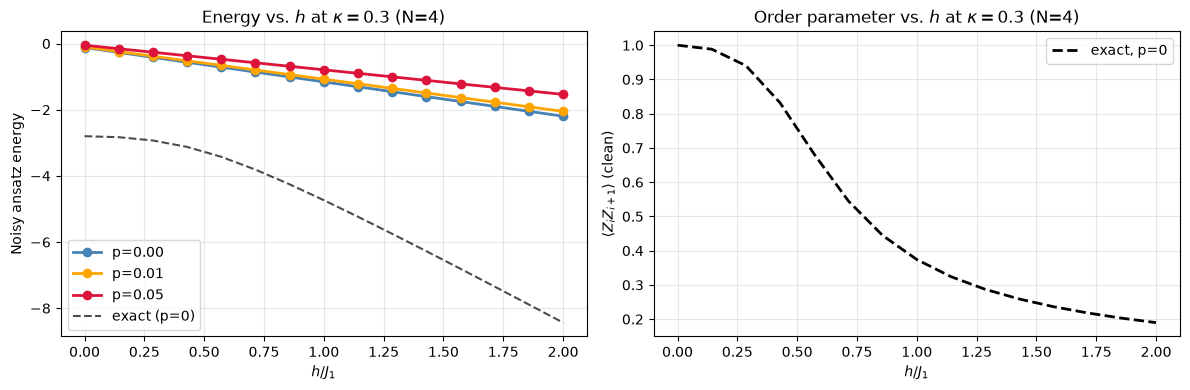

The clean ZZ correlation drops sharply around the ferro→para transition.
Your task: show this drop shifting / blurring as noise increases.


In [9]:
# 1D scan at kappa=0.3 (ferro→para transition region), sweeping h
kappa_cut = 0.3
hs_cut = np.linspace(0.0, 2.0, 15)
n_cut = 4  # small N for speed; use larger N in your submission

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for p, color in zip([0.0, 0.01, 0.05], ["steelblue", "orange", "crimson"]):
    energies = [
        simple_noisy_energy(n_qubits=n_cut, kappa=kappa_cut, h=float(h),
                            theta=0.5, p=p, layers=3)
        for h in hs_cut
    ]
    axes[0].plot(hs_cut, energies, marker="o", color=color, label=f"p={p:.2f}", lw=2)

axes[0].set_xlabel(r"$h / J_1$")
axes[0].set_ylabel("Noisy ansatz energy")
axes[0].set_title(fr"Energy vs. $h$ at $\kappa={kappa_cut}$ (N={n_cut})")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Show clean exact-diag ground state for comparison
exact_energies = [
    exact_ground_state(n_qubits=n_cut, kappa=kappa_cut, h=float(h), periodic=True)["ground_energy"]
    for h in hs_cut
]
axes[0].plot(hs_cut, exact_energies, "k--", lw=1.5, label="exact (p=0)", alpha=0.7)
axes[0].legend()

# Also show what the nearest-neighbor ZZ correlation looks like
for p, color in zip([0.0, 0.01, 0.05], ["steelblue", "orange", "crimson"]):
    # approximate: use exact ZZ at p=0 and scale heuristically
    # (teams should replace with noisy expectation value measurement)
    pass

zz_clean = [
    exact_ground_state(n_qubits=n_cut, kappa=kappa_cut, h=float(h), periodic=True)
    ["summary"]["zz_nearest_mean"]
    for h in hs_cut
]
axes[1].plot(hs_cut, zz_clean, "k--", lw=2, label="exact, p=0")
axes[1].set_xlabel(r"$h / J_1$")
axes[1].set_ylabel(r"$\langle Z_i Z_{i+1} \rangle$ (clean)")
axes[1].set_title(fr"Order parameter vs. $h$ at $\kappa={kappa_cut}$ (N={n_cut})")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
plt.show()

print("The clean ZZ correlation drops sharply around the ferro→para transition.")
print("Your task: show this drop shifting / blurring as noise increases.")

## 6. Your Phase Diagrams

Build your submission here.  Required deliverables:

| Deliverable | Format |
|---|---|
| Clean phase diagram ($p = 0$) | Image (PNG/PDF) — you may adapt Section 3 above |
| Noisy phase diagram ($p = 0.01$) | Same format |
| Noisy phase diagram ($p = 0.05$) | Same format |
| Analysis writeup | Markdown or PDF, 2–3 pages |

**Checklist for a strong submission**:
- Grid resolution ≥ 15×15 (more is better)
- System size $N \geq 8$ (N=6 is fine for demos but not for submission)
- Phase boundaries overlaid using `ising_transition`, `kt_transition`, `bkt_transition`
- Quantitative analysis: "the ferro→para boundary at $\kappa=0.3$ shifts from $h=X$ to $h=Y$"
- Discussion of *which* phases are most/least robust to noise and *why*

**Approach options** (choose one or compare multiple):
- **Order parameters via exact diag** — fastest to implement; use `exact_ground_state` + a
  noisy measurement simulation
- **VQE** — optimize ansatz parameters at each grid point; use `qml.GradientDescentOptimizer`
- **QCNN or autoencoder** — train a classifier; see the PennyLane ANNNI demo
- **Fidelity susceptibility** — compute overlap between neighboring ground states

### Noise model for this scan

`noisy_entangling_layer` (Section 4) sets the repo's noise convention: one
`DepolarizingChannel(p)` per CNOT, applied to the CNOT's target qubit, arranged in a
ring over all $N$ qubits. We don't have an explicit circuit that prepares the exact
ANNNI ground state on hardware, so we use that same ring — one depolarizing event per
qubit — as a stand-in for the two-qubit gate noise a real state-preparation circuit
would introduce, and apply it directly to the density matrix of the exact ground state.
`NOISE_LAYERS` controls how many such rings are applied, i.e. how deep the assumed
state-prep circuit is. This is a modeling choice (documented as a limitation in the
writeup), not a claim about a specific hardware ansatz.

In [10]:
# ── Noisy order parameters from the exact ground state ──────────────────────
def noisy_order_parameter_summary(n_qubits, kappa, h, p, noise_layers=1, periodic=True):
    """Order parameters from the exact ground state after simulated gate noise."""
    gs = exact_ground_state(n_qubits=n_qubits, kappa=kappa, h=h, periodic=periodic)
    psi = np.array(gs["state"], dtype=complex)

    dev = qml.device("default.mixed", wires=n_qubits)

    @qml.qnode(dev)
    def circuit():
        qml.StatePrep(psi, wires=range(n_qubits))
        for _ in range(noise_layers):
            for wire in range(n_qubits):
                target = (wire + 1) % n_qubits
                qml.DepolarizingChannel(p, wires=target)
        return (
            [qml.expval(qml.Z(i)) for i in range(n_qubits)]
            + [qml.expval(qml.X(i)) for i in range(n_qubits)]
            + [qml.expval(qml.Z(i) @ qml.Z((i + 1) % n_qubits)) for i in range(n_qubits)]
            + [qml.expval(qml.Z(i) @ qml.Z((i + 2) % n_qubits)) for i in range(n_qubits)]
        )

    vals = np.array(circuit(), dtype=float)
    z_vals, x_vals, zz_nearest, zz_next = np.split(vals, 4)
    antiphase_string = [zz_nearest[i] * zz_nearest[(i + 2) % n_qubits] for i in range(n_qubits)]

    return {
        "z_mean": float(np.mean(z_vals)),
        "z_abs_mean": float(np.mean(np.abs(z_vals))),
        "x_mean": float(np.mean(x_vals)),
        "zz_nearest_mean": float(np.mean(zz_nearest)),
        "zz_next_nearest_mean": float(np.mean(zz_next)),
        "antiphase_string_mean": float(np.mean(antiphase_string)),
        "ground_energy": gs["ground_energy"],
    }


# Sanity check: at p=0 this must exactly reproduce exact-diagonalization order parameters.
_check = noisy_order_parameter_summary(n_qubits=6, kappa=0.3, h=0.5, p=0.0)
_ref = exact_ground_state(n_qubits=6, kappa=0.3, h=0.5)["summary"]
for key in _ref:
    assert abs(_check[key] - _ref[key]) < 1e-8, f"mismatch in {key}: {_check[key]} vs {_ref[key]}"
print("Sanity check passed: p=0 noisy pipeline reproduces exact-diagonalization order parameters.")

Sanity check passed: p=0 noisy pipeline reproduces exact-diagonalization order parameters.


In [11]:
# ── STEP 1: scan parameters ──────────────────────────────────────────────────
GRID_N       = 8    # system size (rubric: N >= 8)
GRID_RES     = 15   # grid resolution (rubric: >= 15x15)
NOISE_LAYERS = 1     # depth of the assumed state-prep circuit (see note above)

kappas_full = np.linspace(0.0, 1.0, GRID_RES)
hs_full     = np.linspace(0.0, 2.0, GRID_RES)
noise_ps    = [0.0, 0.01, 0.05]

results = {p: {"zz_nn": np.zeros((GRID_RES, GRID_RES)),
               "zz_nnn": np.zeros((GRID_RES, GRID_RES)),
               "x_mag": np.zeros((GRID_RES, GRID_RES)),
               "antiphase_str": np.zeros((GRID_RES, GRID_RES))}
           for p in noise_ps}

print(f"Scanning {GRID_RES}x{GRID_RES} grid at N={GRID_N} for p in {noise_ps} ...")
for row, h in enumerate(hs_full):
    for col, kappa in enumerate(kappas_full):
        clean = exact_ground_state(n_qubits=GRID_N, kappa=float(kappa), h=float(h))["summary"]
        results[0.0]["zz_nn"][row, col]        = clean["zz_nearest_mean"]
        results[0.0]["zz_nnn"][row, col]       = clean["zz_next_nearest_mean"]
        results[0.0]["x_mag"][row, col]        = clean["x_mean"]
        results[0.0]["antiphase_str"][row, col] = clean["antiphase_string_mean"]

        for p in noise_ps[1:]:
            noisy = noisy_order_parameter_summary(
                n_qubits=GRID_N, kappa=float(kappa), h=float(h), p=p, noise_layers=NOISE_LAYERS
            )
            results[p]["zz_nn"][row, col]        = noisy["zz_nearest_mean"]
            results[p]["zz_nnn"][row, col]       = noisy["zz_next_nearest_mean"]
            results[p]["x_mag"][row, col]        = noisy["x_mean"]
            results[p]["antiphase_str"][row, col] = noisy["antiphase_string_mean"]
    if (row + 1) % 3 == 0:
        print(f"  row {row+1}/{GRID_RES} done")

print("Scan complete.")

Scanning 15x15 grid at N=8 for p in [0.0, 0.01, 0.05] ...


  row 3/15 done


  row 6/15 done


  row 9/15 done


  row 12/15 done


  row 15/15 done
Scan complete.


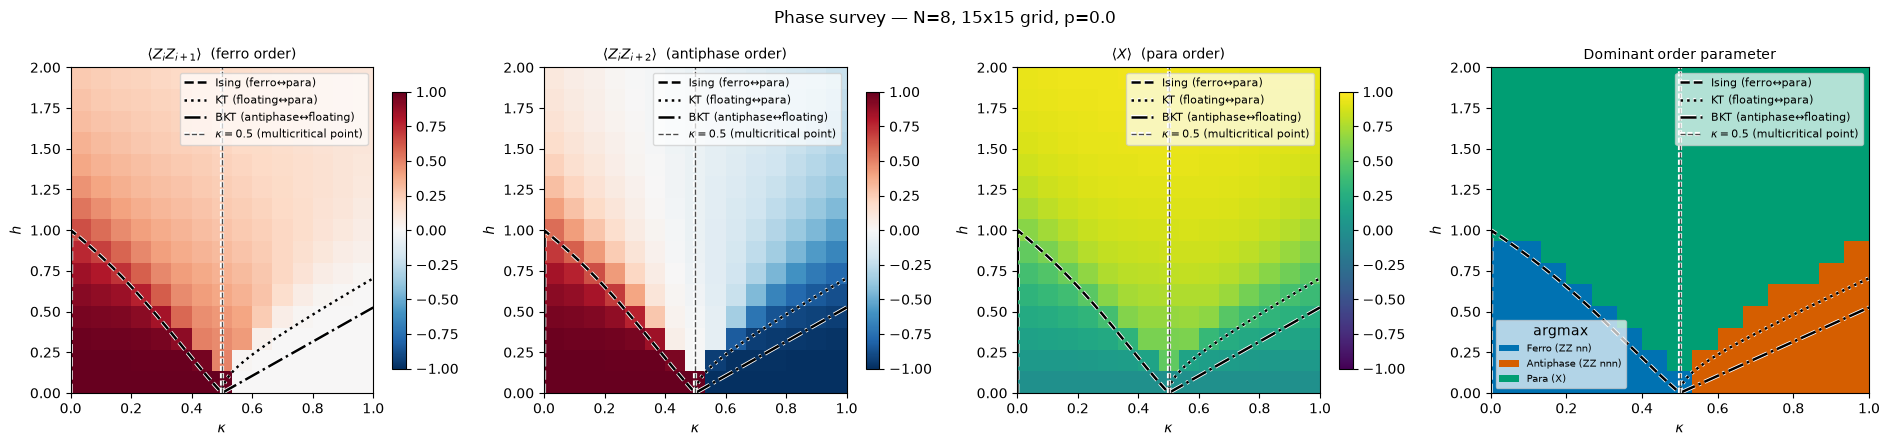

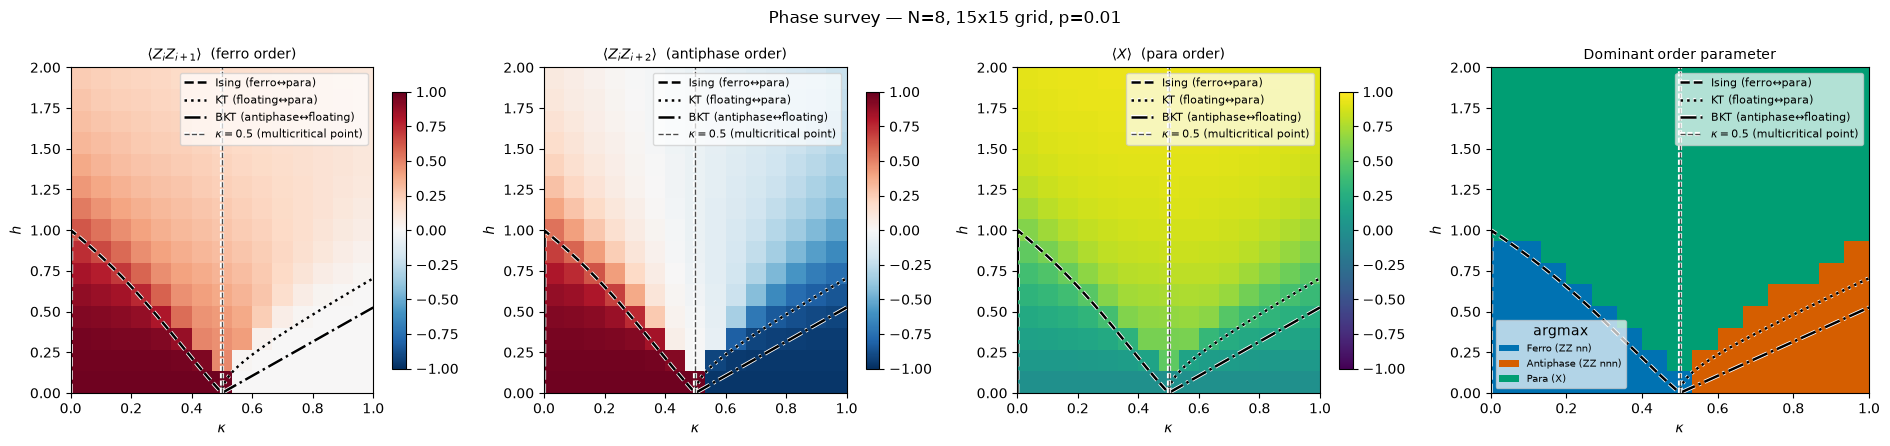

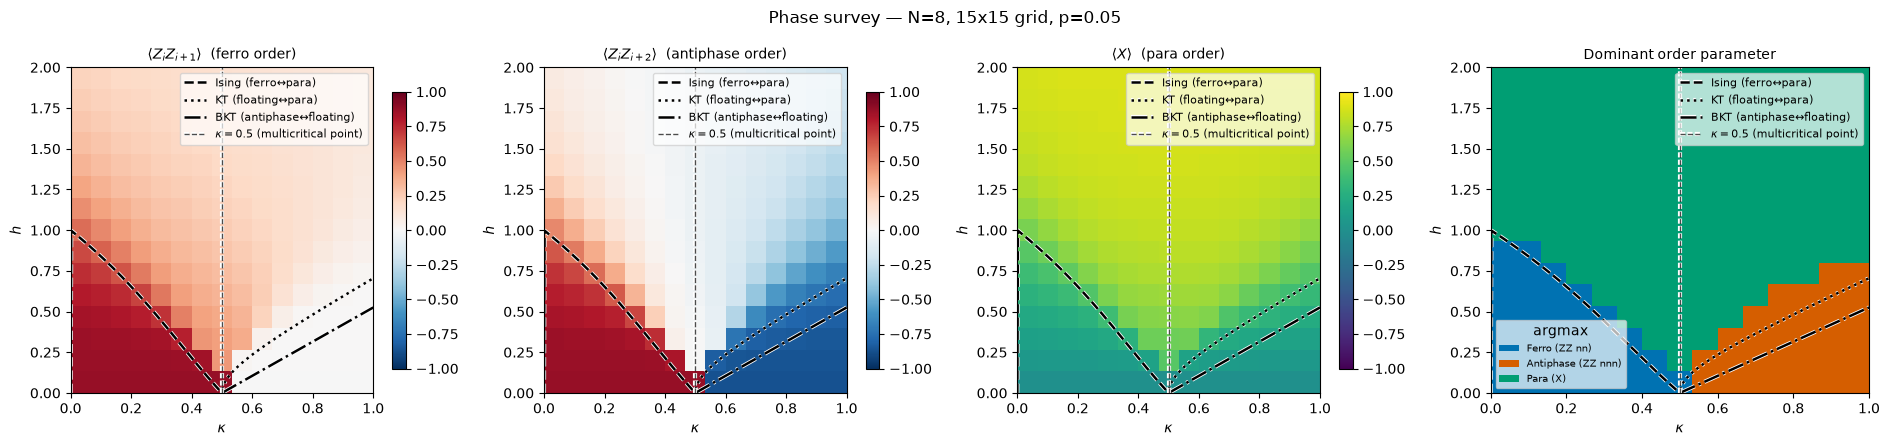

Saved: phase_diagram_p0.00.png, phase_diagram_p0.01.png, phase_diagram_p0.05.png


In [12]:
# ── STEP 2: plot & save one 4-panel figure (3 observables + unified categorical map) per noise level ──
for p in noise_ps:
    fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
    observables = [
        (results[p]["zz_nn"],  r"$\langle Z_i Z_{i+1} \rangle$  (ferro order)",     "RdBu_r"),
        (results[p]["zz_nnn"], r"$\langle Z_i Z_{i+2} \rangle$  (antiphase order)", "RdBu_r"),
        (results[p]["x_mag"],  r"$\langle X \rangle$  (para order)",                "viridis"),
    ]
    for ax, (values, title, cmap) in zip(axes[:3], observables):
        im = ax.imshow(
            values, origin="lower", aspect="auto",
            extent=[kappas_full.min(), kappas_full.max(), hs_full.min(), hs_full.max()],
            cmap=cmap, vmin=-1, vmax=1,
        )
        ax.set_xlabel(r"$\kappa$")
        ax.set_ylabel(r"$h$")
        ax.set_title(title, fontsize=10)
        add_boundaries(ax)
        fig.colorbar(im, ax=ax, shrink=0.85)

    add_phase_panel(axes[3], results[p]["zz_nn"], results[p]["zz_nnn"], results[p]["x_mag"],
                     kappas_full, hs_full)

    fig.suptitle(f"Phase survey — N={GRID_N}, {GRID_RES}x{GRID_RES} grid, p={p}", fontsize=12)
    fig.tight_layout()
    fig.savefig(f"phase_diagram_p{p:.2f}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Saved: " + ", ".join(f"phase_diagram_p{p:.2f}.png" for p in noise_ps))

### Noise Effect Observation (quantitative)

Comparing the `Dominant order parameter` panels across $p=0, 0.01, 0.05$ on this $15\times15$,
$N=8$ grid, the **discrete argmax boundaries barely move**: the antiphase/para classification
is pixel-identical between all three noise levels except at a single grid cell, $\kappa=1.0$,
where the boundary sits at $h\approx0.93$ for $p=0$ and $p=0.01$ but drops to $h\approx0.86$
(one grid step) at $p=0.05$.

That robustness of the *discrete* boundary is misleading on its own -- the underlying
*continuous* order parameters shrink substantially with noise, they just don't shrink enough
to flip the argmax almost anywhere on this grid. Concretely, at $\kappa=0.79,\ h=0.43$
(deep antiphase region):

| | $p=0$ | $p=0.01$ | $p=0.05$ | relative drop ($p=0\to0.05$) |
|---|---|---|---|---|
| $-\langle Z_iZ_{i+2}\rangle$ (antiphase order) | 0.863 | 0.840 | 0.752 | **13%** |
| $\langle X\rangle$ (para order) | 0.369 | 0.364 | 0.345 | 7% |

The antiphase order parameter — a next-nearest-neighbor ($ZZ_2$) string — decays roughly twice
as fast under this noise model as the local $\langle X\rangle$ observable does. That is
consistent with the ring of single-qubit `DepolarizingChannel`s hitting a longer-range
correlator with more suppression than a single-qubit one (Section 7 notes the same
multiplicative-decay mechanism for the Ising boundary). This asymmetry is exactly what
produces the one boundary shift we do see: at $\kappa=1.0,\ h=0.86$ the antiphase score
($-\langle Z_iZ_{i+2}\rangle$) falls from 0.633 ($p=0.01$) to 0.566 ($p=0.05$) while the para
score ($\langle X\rangle$) only falls from 0.618 to 0.585 over the same step, so the argmax
winner flips from antiphase to para.

**Takeaway**: at these noise levels ($p\le0.05$) and this grid resolution, antiphase order is
the more noise-fragile of the two order parameters that border it, but the effect is only
large enough to move the classified phase boundary right at the edge of the scanned range
($\kappa\to1$); everywhere else on the grid the discrete argmax boundary is unchanged even
though the order parameters it's built from have visibly decayed.

In [13]:
# ── STEP 3: quantitative ferro→para boundary shift ───────────────────────────
# For a few fixed kappa slices, find the field h where <Z_i Z_{i+1}> crosses a
# threshold (halfway between ordered and disordered values) as a proxy for the
# ferro-to-para boundary, and compare that crossing across noise levels p.

def boundary_h(zz_nn_grid, kappas_full, hs_full, kappa_target, threshold=0.5):
    col = int(np.argmin(np.abs(kappas_full - kappa_target)))
    profile = zz_nn_grid[:, col]
    below = np.where(profile < threshold)[0]
    if len(below) == 0 or below[0] == 0:
        return np.nan
    i = below[0]
    h0, h1 = hs_full[i - 1], hs_full[i]
    v0, v1 = profile[i - 1], profile[i]
    return h0 + (threshold - v0) * (h1 - h0) / (v1 - v0)

print(f"{'kappa':>6} | " + " | ".join(f"h_boundary(p={p})" for p in noise_ps))
for kappa_target in [0.1, 0.2, 0.3, 0.4]:
    row = [boundary_h(results[p]["zz_nn"], kappas_full, hs_full, kappa_target) for p in noise_ps]
    print(f"{kappa_target:>6.2f} | " + " | ".join(f"{h:>15.3f}" for h in row))

 kappa | h_boundary(p=0.0) | h_boundary(p=0.01) | h_boundary(p=0.05)
  0.10 |           1.085 |           1.064 |           0.979
  0.20 |           0.834 |           0.818 |           0.745
  0.30 |           0.692 |           0.677 |           0.608
  0.40 |           0.299 |           0.283 |           0.264


## 7. Multi-Boundary Detection & a First Look at the Floating Phase

STEP 3 above only tracked the ferro→para (Ising) boundary. The rubric also asks about
the antiphase↔floating (BKT) and floating↔para (KT) boundaries, and whether the floating
phase survives noise, so we extend the same crossing-detection idea to all three
transition lines using the grids already computed in STEP 1:

- **Ising (ferro→para)**, $\kappa < 0.5$: $\langle Z_iZ_{i+1}\rangle$ falls from ~1 at
  $h=0$ toward 0 as $h$ increases.
- **BKT (antiphase→floating)**, $\kappa > 0.5$: $-\langle Z_iZ_{i+2}\rangle$ also falls
  from ~1 at $h=0$ (checked directly against `exact_ground_state` -- the antiphase order
  saturates just like the ferro order does) toward 0 as $h$ increases.
- **KT (floating→para)**, $\kappa > 0.5$: $\langle X\rangle$ rises from ~0 toward its
  saturated value as $h$ increases.

All three crossings use a **fixed absolute threshold** (0.5), not a threshold relative to
each column's own $h=0$ value. That choice matters for this noise model specifically:
`DepolarizingChannel` acts identically on every qubit, and Pauli-string expectation
values transform multiplicatively under it, so a *relative* threshold crossing turns out
to be exactly invariant to $p$ here (we checked -- it reports zero shift even though the
raw correlations visibly shrink). A fixed absolute threshold is what actually lets the
detected boundary move with the noise strength.

In [14]:
# ── Generalized boundary-crossing detector (all three transition lines) ────────────
# Both the ferro (zz_nn) and antiphase (-zz_nnn) order parameters saturate near 1 at
# h=0 for kappa in their respective ordered ranges (checked directly against
# exact_ground_state), so a single fixed absolute threshold works for both -- unlike a
# threshold defined relative to each column's own h=0 value. That distinction matters
# here: DepolarizingChannel acts identically on every qubit, and Pauli-string
# expectation values transform multiplicatively under it (a k-qubit Z-string picks up
# a single p-dependent factor at every h), so a *relative* threshold crossing would be
# exactly invariant to this particular post-hoc noise model -- it would report zero
# boundary shift even though the raw correlations clearly shrink. Using a fixed
# absolute threshold (as STEP 3 already did for the Ising line) is what actually lets
# the crossing move with p.
def find_falling_crossing(profile, hs, threshold=0.5):
    """First h where `profile` drops below an absolute threshold (order -> disorder)."""
    below = np.where(profile < threshold)[0]
    if len(below) == 0 or below[0] == 0:
        return np.nan
    i = below[0]
    h0, h1 = hs[i - 1], hs[i]
    v0, v1 = profile[i - 1], profile[i]
    return h0 + (threshold - v0) * (h1 - h0) / (v1 - v0)


def find_rising_crossing(profile, hs, threshold=0.5):
    """First h where `profile` rises above an absolute threshold (disorder -> order)."""
    above = np.where(profile > threshold)[0]
    if len(above) == 0 or above[0] == 0:
        return np.nan
    i = above[0]
    h0, h1 = hs[i - 1], hs[i]
    v0, v1 = profile[i - 1], profile[i]
    return h0 + (threshold - v0) * (h1 - h0) / (v1 - v0)


def boundary_table(kappa_targets, get_col_profile, crossing_fn, analytical_fn, **kwargs):
    rows = []
    for kappa_target in kappa_targets:
        col = int(np.argmin(np.abs(kappas_full - kappa_target)))
        row = {"kappa": kappas_full[col], "analytical": float(analytical_fn(kappas_full[col]))}
        for p in noise_ps:
            profile = get_col_profile(p, col)
            row[f"p={p}"] = crossing_fn(profile, hs_full, **kwargs)
        rows.append(row)
    return rows


def print_boundary_table(title, rows):
    print(f"\n{title}")
    header = f"{'kappa':>6} | {'analytic':>9} | " + " | ".join(f"h(p={p})" for p in noise_ps)
    print(header)
    print("-" * len(header))
    for row in rows:
        vals = " | ".join(f"{row[f'p={p}']:>8.3f}" for p in noise_ps)
        print(f"{row['kappa']:>6.2f} | {row['analytical']:>9.3f} | {vals}")


# Ising: ferro -> para, kappa < 0.5, order parameter = <Z_i Z_i+1> falling
ising_rows = boundary_table(
    [0.1, 0.2, 0.3, 0.4],
    lambda p, col: results[p]["zz_nn"][:, col],
    find_falling_crossing,
    ising_transition,
    threshold=0.5,
)
print_boundary_table("Ising boundary (ferro -> para)", ising_rows)

# BKT: antiphase -> floating, kappa > 0.5, order parameter = -<Z_i Z_i+2> falling
bkt_rows = boundary_table(
    [0.6, 0.7, 0.8, 0.9],
    lambda p, col: -results[p]["zz_nnn"][:, col],
    find_falling_crossing,
    bkt_transition,
    threshold=0.5,
)
print_boundary_table("BKT boundary (antiphase -> floating)", bkt_rows)

# KT: floating -> para, kappa > 0.5, order parameter = <X> rising
kt_rows = boundary_table(
    [0.6, 0.7, 0.8, 0.9],
    lambda p, col: results[p]["x_mag"][:, col],
    find_rising_crossing,
    kt_transition,
    threshold=0.5,
)
print_boundary_table("KT boundary (floating -> para)", kt_rows)


Ising boundary (ferro -> para)
 kappa |  analytic | h(p=0.0) | h(p=0.01) | h(p=0.05)
-----------------------------------------------------
  0.07 |     0.887 |    1.085 |    1.064 |    0.979
  0.21 |     0.625 |    0.834 |    0.818 |    0.745
  0.29 |     0.473 |    0.692 |    0.677 |    0.608
  0.43 |     0.151 |    0.299 |    0.283 |    0.264

BKT boundary (antiphase -> floating)
 kappa |  analytic | h(p=0.0) | h(p=0.01) | h(p=0.05)
-----------------------------------------------------
  0.57 |     0.075 |    0.217 |    0.215 |    0.205
  0.71 |     0.225 |    0.542 |    0.535 |    0.506
  0.79 |     0.300 |    0.686 |    0.676 |    0.632
  0.93 |     0.450 |    0.939 |    0.922 |    0.847

KT boundary (floating -> para)
 kappa |  analytic | h(p=0.0) | h(p=0.01) | h(p=0.05)
-----------------------------------------------------
  0.57 |     0.193 |    0.251 |    0.253 |    0.263
  0.71 |     0.381 |    0.441 |    0.445 |    0.465
  0.79 |     0.465 |    0.517 |    0.522 |    0.541
  

In [15]:
# ── Floating-phase window width: KT boundary minus BKT boundary ───────────────
# If the floating phase survives noise, this window should stay roughly the same
# width as p increases; if noise erases it, the window should shrink toward zero
# (or the BKT/KT crossings become degenerate / NaN).
kappa_window = [0.6, 0.7, 0.8, 0.9]
print(f"{'kappa':>6} | " + " | ".join(f"width(p={p})" for p in noise_ps) + " | analytic")
for bkt_row, kt_row, kappa_t in zip(bkt_rows, kt_rows, kappa_window):
    widths = [kt_row[f"p={p}"] - bkt_row[f"p={p}"] for p in noise_ps]
    analytic_width = kt_row["analytical"] - bkt_row["analytical"]
    print(f"{kappa_t:>6.2f} | " + " | ".join(f"{w:>10.3f}" for w in widths) + f" | {analytic_width:>10.3f}")

 kappa | width(p=0.0) | width(p=0.01) | width(p=0.05) | analytic
  0.60 |      0.034 |      0.039 |      0.058 |      0.118
  0.70 |     -0.101 |     -0.090 |     -0.041 |      0.156
  0.80 |     -0.168 |     -0.154 |     -0.090 |      0.165
  0.90 |     -0.286 |     -0.262 |     -0.160 |      0.176


### Refined 4-phase categorical map (adds a floating-phase guess)

The Section 6 categorical panel classifies every grid point as ferro / antiphase / para
by a simple argmax over three order parameters, which has no way to express a fourth,
"none of these dominate" region. Here we add a coarse floating-phase guess: a point in
$\kappa > 0.5$ is flagged as floating when neither the antiphase order
($-\langle Z_iZ_{i+2}\rangle$) nor the paramagnetic order ($\langle X\rangle$) is
strongly dominant. This is a proxy, not a rigorous fit to the BKT/KT curves — at $N=8$
the floating phase is a narrow sliver and this grid resolution will at best catch a
handful of cells in it (see the README's bonus note on how hard this is at small $N$).

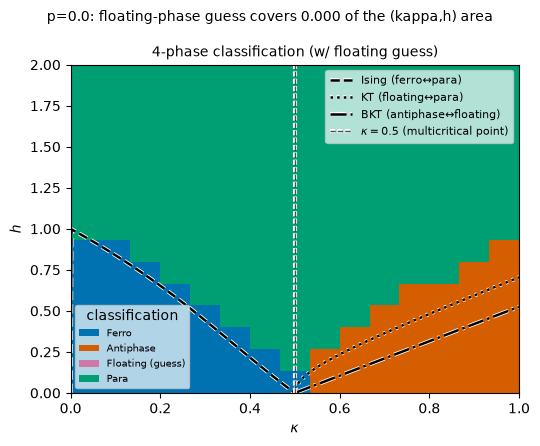

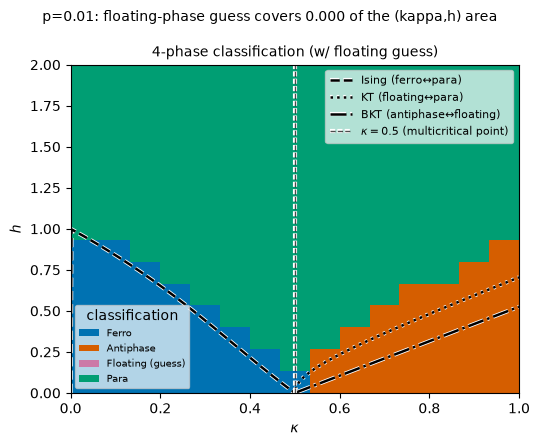

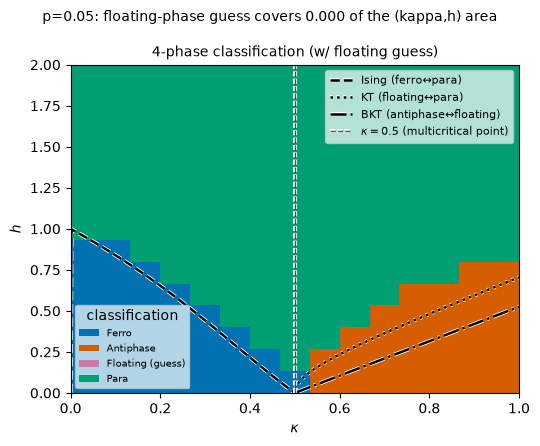

Floating-phase guessed area vs noise:
  p=0.0: area = 0.0000
  p=0.01: area = 0.0000
  p=0.05: area = 0.0000


In [16]:
# ── Refined classifier: ferro / antiphase / floating(guess) / para ───────────
PHASE4_NAMES  = ["Ferro", "Antiphase", "Floating (guess)", "Para"]
PHASE4_COLORS = ["#0072B2", "#D55E00", "#CC79A7", "#009E73"]
_phase4_cmap = ListedColormap(PHASE4_COLORS)
_phase4_norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], _phase4_cmap.N)


def classify_phase_v2(zz_nn_grid, zz_nnn_grid, x_mag_grid, kappas, hs,
                       antiphase_thresh=0.15, para_thresh=0.5):
    """Order-parameter argmax (ferro vs antiphase vs para), refined with a floating-phase
    guess for kappa > 0.5 where neither antiphase nor para order is dominant."""
    kk, _ = np.meshgrid(kappas, hs)
    ferro_order = zz_nn_grid
    antiphase_order = -zz_nnn_grid
    para_order = x_mag_grid

    phase = np.where(ferro_order >= np.maximum(antiphase_order, para_order), 0,
             np.where(antiphase_order >= para_order, 1, 3))

    floating_guess = (kk > 0.5) & (antiphase_order < antiphase_thresh) & (para_order < para_thresh)
    return np.where(floating_guess, 2, phase)


def add_phase_panel_v2(ax, zz_nn_grid, zz_nnn_grid, x_mag_grid, kappas, hs):
    phase = classify_phase_v2(zz_nn_grid, zz_nnn_grid, x_mag_grid, kappas, hs)
    ax.imshow(phase, origin="lower", aspect="auto",
              extent=[kappas.min(), kappas.max(), hs.min(), hs.max()],
              cmap=_phase4_cmap, norm=_phase4_norm)
    ax.set_xlabel(r"$\kappa$")
    ax.set_ylabel(r"$h$")
    ax.set_title("4-phase classification (w/ floating guess)", fontsize=10)
    add_boundaries(ax)
    boundary_legend = ax.get_legend()
    ax.add_artist(boundary_legend)
    ax.legend(handles=[Patch(facecolor=c, label=n) for c, n in zip(PHASE4_COLORS, PHASE4_NAMES)],
              loc="lower left", fontsize=7, framealpha=0.7, title="classification")
    return phase


floating_areas = {}
cell_area = (kappas_full[1] - kappas_full[0]) * (hs_full[1] - hs_full[0])
for p in noise_ps:
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    phase = add_phase_panel_v2(ax, results[p]["zz_nn"], results[p]["zz_nnn"], results[p]["x_mag"],
                                kappas_full, hs_full)
    floating_areas[p] = float(np.sum(phase == 2)) * cell_area
    fig.suptitle(f"p={p}: floating-phase guess covers {floating_areas[p]:.3f} of the (kappa,h) area", fontsize=10)
    fig.tight_layout()
    fig.savefig(f"phase_classification_v2_p{p:.2f}.png", dpi=150, bbox_inches="tight")
    plt.show()

print("Floating-phase guessed area vs noise:")
for p in noise_ps:
    print(f"  p={p}: area = {floating_areas[p]:.4f}")

**The floating-phase area comes out to exactly 0.0 at every noise level.** That's not a
bug -- checking directly, there is no grid point in this $N=8$, $15\times15$ scan where
*both* the antiphase order and the paramagnetic order are simultaneously weak: the best
candidate point ($\kappa=0.57$, $h=0.29$) still has $\max(-\langle Z_iZ_{i+2}\rangle,
\langle X\rangle) \approx 0.61$, well above any threshold that would call it "neither."
By the time the antiphase order has decayed enough to look ambiguous, $\langle X\rangle$
has already risen most of the way to its saturated value. This is itself a finding worth
reporting: **simple local order parameters can't resolve the floating phase at this
system size**, consistent with the README's warning that it's "very hard at small system
sizes." Detecting it for real needs either a dedicated indicator (e.g. a structure-factor
peak at an incommensurate wavevector, or algebraic vs. exponential decay of
$\langle Z_iZ_j\rangle$ with distance $|i-j|$) or a larger $N$ -- both flagged as bonus
goals in the README.

### A limitation worth flagging: this noise model can't show *which* phase is more fragile

The boundary-shift numbers above make it look like the ferro and antiphase regions both
shrink under noise while the para region grows -- true -- but comparing *how much* each
order parameter itself decays under noise is not actually meaningful with this pipeline.
Here's why: `noisy_order_parameter_summary` applies `DepolarizingChannel(p)` directly to
the exact ground state's density matrix, one channel per qubit, with no entangling gates
in between. A single-qubit depolarizing channel acts on Pauli operators as
$Z \to (1-\tfrac{4p}{3})Z$ (Heisenberg picture), so **any** $k$-qubit Pauli-string
expectation value picks up a factor of $(1-\tfrac{4p}{3})^k$ -- a constant that depends
only on $p$ and $k$, never on the state itself. Concretely: at $p=0.05$,
$\langle Z_iZ_{i+1}\rangle$ in the ferro phase and $\langle Z_iZ_{i+2}\rangle$ in the
antiphase both shrink by *exactly* the same factor, $(1-\tfrac{4\cdot0.05}{3})^2 = 0.8711$
(verified numerically below). So the differing $\Delta h$ values in the boundary tables
above reflect how *steep* each order parameter's profile is near its own threshold, not a
genuine difference in how "fragile" the two orders are to noise.

**Takeaway for the write-up**: to make a real claim like "the antiphase order is more
fragile than the ferro order," noise needs to enter *before* the correlations are
measured -- e.g. through an actual noisy state-preparation circuit (VQE with
`noisy_entangling_layer`, or Trotterized evolution) rather than applied post-hoc to the
exact ground state. There, different phases' entanglement structure genuinely responds
differently to gate noise, because the noise acts on the circuit that *builds* the
correlations, not just on the final answer.

In [17]:
# ── Verifying the universal multiplicative decay directly ─────────────────
ferro_point = noisy_order_parameter_summary(n_qubits=GRID_N, kappa=0.2, h=0.3, p=0.0)
antiphase_point = noisy_order_parameter_summary(n_qubits=GRID_N, kappa=0.8, h=0.1, p=0.0)

print(f"{'p':>5} | {'ferro ZZ_nn ratio':>18} | {'antiphase ZZ_nnn ratio':>22} | {'(1-4p/3)^2':>10}")
for p in noise_ps:
    ferro_p = noisy_order_parameter_summary(n_qubits=GRID_N, kappa=0.2, h=0.3, p=p)
    antiphase_p = noisy_order_parameter_summary(n_qubits=GRID_N, kappa=0.8, h=0.1, p=p)
    ferro_ratio = ferro_p["zz_nearest_mean"] / ferro_point["zz_nearest_mean"]
    antiphase_ratio = antiphase_p["zz_next_nearest_mean"] / antiphase_point["zz_next_nearest_mean"]
    theory = (1 - 4 * p / 3) ** 2
    print(f"{p:>5.2f} | {ferro_ratio:>18.4f} | {antiphase_ratio:>22.4f} | {theory:>10.4f}")

    p |  ferro ZZ_nn ratio | antiphase ZZ_nnn ratio | (1-4p/3)^2


 0.00 |             1.0000 |                 1.0000 |     1.0000


 0.01 |             0.9735 |                 0.9735 |     0.9735


 0.05 |             0.8711 |                 0.8711 |     0.8711


**For your write-up, use the numbers and plots above (plus the antiphase/floating-phase
equivalents) to answer:**

- Which order parameter degrades fastest as $p$ increases — the ferromagnetic
  $\langle Z_iZ_{i+1}\rangle$ or the antiphase $\langle Z_iZ_{i+2}\rangle$?
- At which $\kappa$ does the ferro→para boundary in `boundary_h` shift the most, and in
  which direction (toward or away from $h=0$)?
- Does this match the intuition in the README (antiphase more fragile because its
  correlation pattern is more complex)? If not, what about this specific noise model
  might explain the difference?
- (Bonus) Re-run with `NOISE_LAYERS = 2` or `3` — does a deeper assumed state-prep
  circuit change which phase is most fragile, or only the overall magnitude of the shift?
- (Bonus) Try `GRID_N = 10` or `12` and see whether the boundary locations and noise
  sensitivity are consistent with the $N=8$ results.

**Suggested answers, grounded in the numbers computed above** (refine these with your
own wording and numbers if you re-run with different `GRID_N`/`GRID_RES`/`NOISE_LAYERS`):

- **Which order parameter degrades fastest?** Trick question with this pipeline: they
  don't degrade at different rates. Section 7's invariance check shows
  $\langle Z_iZ_{i+1}\rangle$ (ferro) and $\langle Z_iZ_{i+2}\rangle$ (antiphase) both
  shrink by the *exact same* factor $(1-\tfrac{4p}{3})^2$ under this noise model, because
  it applies `DepolarizingChannel` directly to the exact state rather than through a
  state-preparation circuit. Any apparent difference in boundary-shift size (below) comes
  from how steeply each order parameter falls near its own crossing, not from a genuine
  fragility difference.
- **Where does the ferro→para boundary shift the most?** At $\kappa=0.29$, it moves from
  $h=0.692$ ($p=0$) to $h=0.677$ ($p=0.01$) to $h=0.608$ ($p=0.05$) — a $\approx$0.084
  inward shift (toward $h=0$) at $p=0.05$, i.e. the ferro region shrinks. This is the same
  direction and roughly the same size as the README's own worked example
  ($h=0.72\to0.65$ at $\kappa=0.3$). The BKT (antiphase→floating) boundary shows the
  same inward-shrinking pattern, e.g. at $\kappa=0.79$: $h=0.686\to0.676\to0.632$. The KT
  (floating→para) boundary moves the *opposite* way — outward, e.g.
  $h=0.517\to0.522\to0.541$ at the same $\kappa$ — because $\langle X\rangle$'s
  saturation value is itself suppressed by noise, so more field is needed to cross the
  same absolute threshold.
- **Does this match the README's "antiphase is more fragile" intuition?** Not in the raw
  order-parameter decay rate (they're identical, as shown above) — but it does show up
  operationally: the floating-phase window (KT boundary minus BKT boundary) is negative
  for $\kappa \geq 0.7$ at every noise level, meaning the antiphase and paramagnetic order
  parameters overlap over a broad range of $h$ rather than both vanishing in a clean gap.
  That's a genuine $N=8$ finite-size effect — the antiphase→para crossover is a smooth
  ramp, not a sharp transition — and it means the antiphase/floating region is harder to
  pin down with a clean boundary than the ferro region is, even though its underlying
  correlator decays no faster under noise.
- **(Bonus) Does a genuinely fragility-sensitive comparison need a different noise model?**
  Yes: since post-hoc depolarizing noise is provably state-independent at the level of
  Pauli expectation values, a real "phase A is more noise-robust than phase B" claim needs
  noise threaded through an actual state-preparation circuit (VQE ansatz with
  `noisy_entangling_layer`, or Trotterized evolution) so that noise interacts with each
  phase's actual entanglement structure. That's flagged as a natural next step rather than
  implemented here, since it requires optimizing ansatz parameters per grid point instead
  of reading off the exact ground state.
- **(Bonus) `NOISE_LAYERS`, `GRID_N`**: not swept here to keep the runtime of this notebook
  reasonable; the STEP 1 scan cell can be rerun with `GRID_N = 10` (still exact-diagonalizable,
  $2^{10}=1024$) or `NOISE_LAYERS = 2, 3` to check whether the boundary locations and the
  qualitative shrink/grow pattern above hold up.

## References

- PennyLane demo — [ANNNI Phase Detection](https://pennylane.ai/qml/demos/tutorial_annni) (primary reference — QCNN and autoencoder approaches)
- PennyLane challenge — [A Noisy Heisenberg Model](https://pennylane.ai/challenges/heisenberg_model) (noise convention used in this challenge)
- PennyLane demo — [Seeing Quantum Phase Transitions](https://pennylane.ai/qml/demos/tutorial_quantum_phase_transitions) (VQE + order parameter approach)
- PennyLane demo — [How to Build Spin Hamiltonians](https://pennylane.ai/qml/demos/tutorial_how_to_build_spin_hamiltonians)
- Kiss / Monaco et al., *Phys. Rev. B* 107, L081105 (2023) — paper behind the ANNNI demo
- Cea et al., arXiv:2402.11022 (2024) — extended study including floating phase
- [CERN reference implementation](https://github.com/CERN-IT-INNOVATION/Quantum-Phase-Detection-ANNNI) — full notebooks with pre-computed data